<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/05_Linear_Models_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Linear Models and Regularization

**Nama:** Muhammad Habibie Rabbani  
**Kelas:** TK-47-04  
**Program Studi:** Teknik Komputer, Telkom University

**Referensi utama:** John Sukup, *scikit-learn Cookbook*, edisi ketiga, Packt Publishing (2025), Chapter 5. Kode diadaptasi dari [notebook dan solusi latihan resmi penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_5). Urutan metode dan dataset mengacu pada sumber tersebut; penjelasan bahasa Indonesia serta pemeriksaan tambahan disusun untuk pembelajaran. Lisensi kode sumber terdapat dalam `THIRD_PARTY_NOTICES.md`.

## Tujuan pembelajaran

1. Menjelaskan Ordinary Least Squares, Ridge, Lasso, dan ElasticNet beserta fungsi objektifnya.
2. Mengaudit multikolinearitas, skala target, dan interpretasi koefisien.
3. Memilih kekuatan regularisasi menggunakan training CV dengan preprocessing di dalam estimator.
4. Memodelkan pola nonlinier memakai polynomial features dan spline basis.
5. Menyelesaikan tiga latihan regularisasi serta menganalisis residual dan keterbatasan model.

## Peta reproduksi dan adaptasi

| Resep/latihan sumber | Bagian notebook | Reproduksi dan penyesuaian |
|---|---|---|
| Dataset multikolinearitas + LinearRegression | 2–3 | 1.000×100 data sintetis; generator diberi seed lengkap |
| Ridge dan Lasso | 4 | Alpha resep dipertahankan; metrik numerik serta baseline |
| ElasticNet dan coefficient paths | 5 | Model resep + path tujuh alpha/lima l1_ratio, dengan skala terstandar untuk path |
| Pemilihan regularisasi | 6 | Tambahan pipeline, scaling target di dalam fold, dan training CV |
| Polynomial Regression | 7 | Dataset sinus buku, degree 1–5; pemilihan berdasarkan CV |
| Spline basis | 8 | Degree 3 dan knots 3/5/7; skor test, bukan hanya training |
| Latihan 1–3 | 9–11 | Dataset dan parameter Ridge, Lasso, ElasticNet mengikuti solusi sumber |

**Koreksi sumber:** gambar untuk regresi multivariat dibedakan dari garis regresi sederhana; degree/knots tidak dipilih menggunakan test; grafik tidak di-fit ulang pada seluruh data evaluasi; spline regression tidak harus melewati setiap observasi. Regularisasi tidak selalu meningkatkan skor test.

**Cara menjalankan:** buka notebook ini sendiri, lalu jalankan semua sel dari atas ke bawah pada kernel baru. Seluruh dataset chapter ini tersedia dalam scikit-learn atau dibuat secara sintetis, sehingga tidak membutuhkan unduhan data. Angka hasil dapat sedikit berubah antarversi pustaka. Visualisasi seluruh data diberi label sebagai eksplorasi; evaluasi prediktif memakai data test yang terpisah.

## 1. Lingkungan dan reproducibility

Seed mengendalikan pembagian data dan algoritma stokastik. Versi pustaka dicetak supaya hasil bisa ditelusuri. Seed yang sama tidak menjamin hasil identik pada semua perangkat dan versi. Setiap notebook menggunakan nama variabel tersendiri dan tidak bergantung pada eksekusi chapter lain.

In [1]:
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

RANDOM_STATE = 123
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = ["#2563A6", "#D97732", "#47916F", "#885DA6", "#C54B62"]
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__, "| Matplotlib:", matplotlib.__version__)
print("Random state:", RANDOM_STATE)

Python: 3.12.14
NumPy: 2.3.5 | pandas: 2.2.3
scikit-learn: 1.8.0 | Matplotlib: 3.10.8
Random state: 123


## 2. Dataset, multikolinearitas, dan audit

Dataset mengikuti resep buku: `make_regression` membuat 1.000 baris, 100 fitur, sepuluh fitur informatif, dan noise 20. Selanjutnya fitur 50–99 diganti dengan salinan bernoise dari fitur 0–49. Target dikalikan 1.000 dan ditambah komponen nonlinier kecil. Seed pada noise tambahan ditetapkan agar run dapat diulang.

**Catatan proses pembentukan data:** target dibuat sebelum sebagian fitur ditimpa. Bila fitur yang ditimpa semula informatif, informasi tersebut tidak lagi tersedia di X akhir. Artinya, rendahnya skor tidak semata-mata disebabkan multikolinearitas. Ini dipertahankan agar sesuai resep, sekaligus dijelaskan agar interpretasinya jujur. Target sintetis tidak memiliki satuan dunia nyata.

Multikolinearitas berarti satu fitur sangat terkait dengan fitur lain. Koefisien OLS dapat berubah besar walaupun prediksi hanya sedikit berubah. Korelasi fitur diperiksa pada training. Tidak ada missing value yang sengaja disisipkan; imputasi tidak ditambahkan tanpa alasan.

Shape: (1000, 100) | missing: 0 | duplicates: 0 | infinite: 0
Originally informative columns overwritten: 7
Target range: (np.float64(-898454.59), np.float64(683148.06))
Training: (800, 100) | test: (200, 100)
Mean correlation of copied feature pairs: 0.995
Training rows with ≥1 univariate IQR flag: 280 of 800


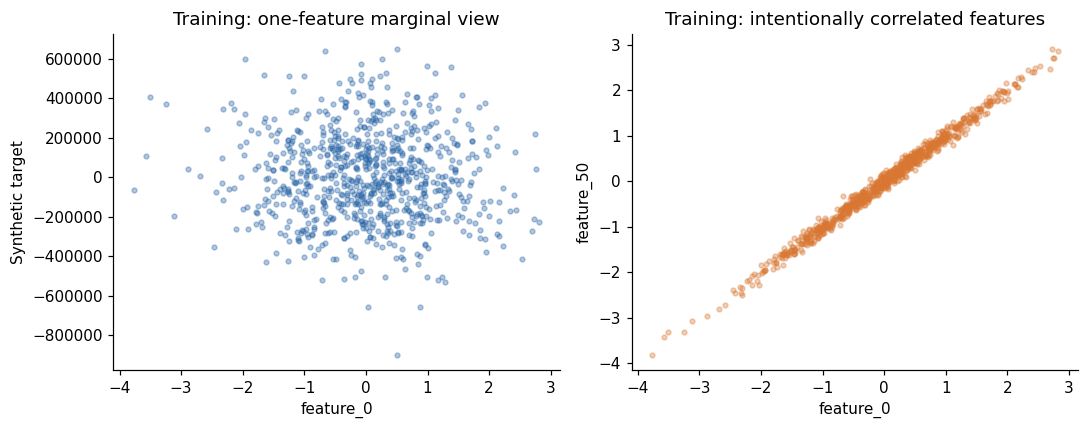

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_initial, y_initial, generating_coef = make_regression(
    n_samples=1000, n_features=100, n_informative=10, noise=20,
    random_state=RANDOM_STATE, coef=True)
rng = np.random.RandomState(RANDOM_STATE)
X_generated = X_initial.copy()
for i in range(50, 100):
    X_generated[:,i] = X_generated[:,i-50] + rng.normal(0, 0.1, 1000)
y_generated = y_initial*1000 + np.sin(X_generated[:,0])*150 + np.exp(X_generated[:,0]/10)
feature_names = [f"feature_{i}" for i in range(100)]
X = pd.DataFrame(X_generated, columns=feature_names)
y = pd.Series(y_generated, name="target")
print("Shape:", X.shape, "| missing:", int(X.isna().sum().sum()),
      "| duplicates:", int(X.duplicated().sum()), "| infinite:", int(np.isinf(X.to_numpy()).sum()))
print("Originally informative columns overwritten:", int(np.count_nonzero(generating_coef[50:])))
print("Target range:", (round(y.min(),2), round(y.max(),2)))
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
assert set(X_train.index).isdisjoint(X_test.index)
assert np.isfinite(X.to_numpy()).all() and np.isfinite(y).all()
print("Training:", X_train.shape, "| test:", X_test.shape)
paired_correlations = [X_train[f"feature_{i}"].corr(X_train[f"feature_{i+50}"]) for i in range(50)]
print("Mean correlation of copied feature pairs:", round(float(np.mean(paired_correlations)),4))
q1,q3 = X_train.quantile(.25), X_train.quantile(.75)
iqr = q3-q1
flagged = ((X_train < q1-1.5*iqr) | (X_train > q3+1.5*iqr)).any(axis=1)
print("Training rows with ≥1 univariate IQR flag:", int(flagged.sum()), "of", len(X_train))
fig, axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(X_train.iloc[:,0],y_train,s=10,alpha=.35,color=COLORS[0])
axes[0].set(xlabel="feature_0",ylabel="Synthetic target",title="Training: one-feature marginal view")
axes[1].scatter(X_train.iloc[:,0],X_train.iloc[:,50],s=10,alpha=.35,color=COLORS[1])
axes[1].set(xlabel="feature_0",ylabel="feature_50",title="Training: intentionally correlated features")
plt.tight_layout();plt.show()

### Analisis audit

Pada 100 fitur, banyak baris dapat terkena setidaknya satu aturan IQR walaupun semuanya berasal dari generator yang valid. Aturan tersebut merupakan penanda pemeriksaan, bukan alasan otomatis menghapus data. Target yang dikalikan 1.000 membuat MSE membesar kira-kira sejuta kali dibanding target awal; ini bukan bukti model lebih buruk. RMSE dan MAE memakai satuan target, MSE memakai satuan target kuadrat, sedangkan R² tidak bersatuan.

## 3. Ordinary Least Squares (OLS)

Model linear multivariat menulis prediksi sebagai $\hat y=b+\sum_j w_jx_j$. OLS memilih koefisien dan intercept yang meminimalkan jumlah kuadrat residual:

$$\min_{b,w}\sum_{i=1}^{n}(y_i-b-x_i^Tw)^2.$$

Linear berarti linear terhadap **koefisien**, sehingga polynomial regression tetap termasuk model linear setelah fitur basis dibentuk. OLS tidak memerlukan residual normal untuk menghitung prediksi, tetapi asumsi tambahan seperti independensi, bentuk mean yang benar, dan varian residual relevan untuk inferensi serta interpretasi ketidakpastian. Multikolinearitas menyulitkan interpretasi koefisien.

Untuk evaluasi, $R^2=1-\mathrm{SSE}/\mathrm{SST}$ pada data yang dinilai. R² dapat negatif. `DummyRegressor` memprediksi mean training; R² baseline pada test tidak harus tepat nol karena mean training dan test bisa berbeda.

In [3]:
def regression_metrics(name, model, Xtr, Xte, ytr, yte):
    rows=[]
    for split,features,target in [("train",Xtr,ytr),("test",Xte,yte)]:
        pred=model.predict(features)
        mse=mean_squared_error(target,pred)
        rows.append({"model":name,"split":split,"MSE":mse,"RMSE":np.sqrt(mse),
                     "MAE":mean_absolute_error(target,pred),"R²":r2_score(target,pred)})
    return rows

linear_model=LinearRegression().fit(X_train,y_train)
baseline_model=DummyRegressor(strategy="mean").fit(X_train,y_train)
recipe_models={"OLS":linear_model,"Mean baseline":baseline_model}
recipe_metric_rows=regression_metrics("OLS",linear_model,X_train,X_test,y_train,y_test)
recipe_metric_rows+=regression_metrics("Mean baseline",baseline_model,X_train,X_test,y_train,y_test)
display(pd.DataFrame(recipe_metric_rows).round(3))
print("Matrix rank:",linear_model.rank_,"of",X_train.shape[1])
print("Intercept:",round(linear_model.intercept_,3))

Matrix rank: 100 of 100
Intercept: -628.308


,model,split,MSE,RMSE,MAE,R²
0,OLS,train,3.395737e+10,184275.248,147199.078,0.323
1,OLS,test,4.655059e+10,215755.860,173597.056,0.065
2,Mean baseline,train,5.017377e+10,223995.024,179416.105,0.000
3,Mean baseline,test,4.978558e+10,223126.818,177968.715,-0.000


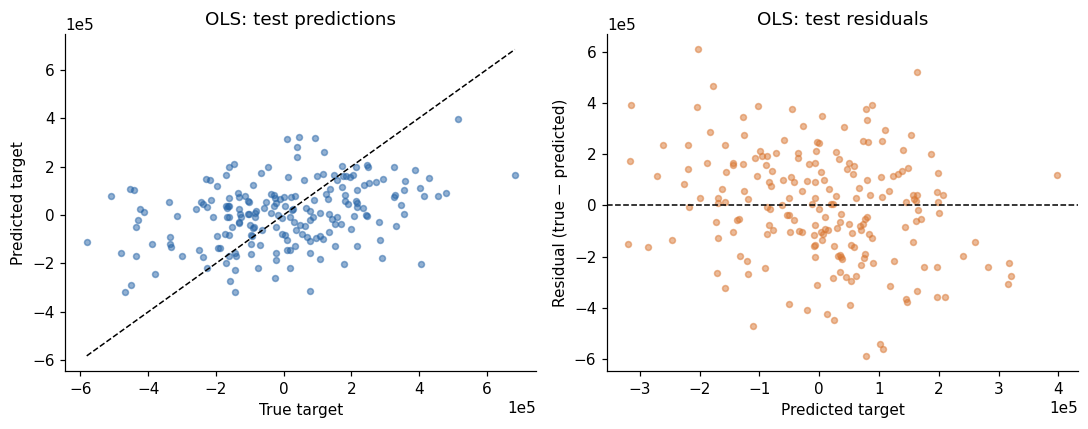

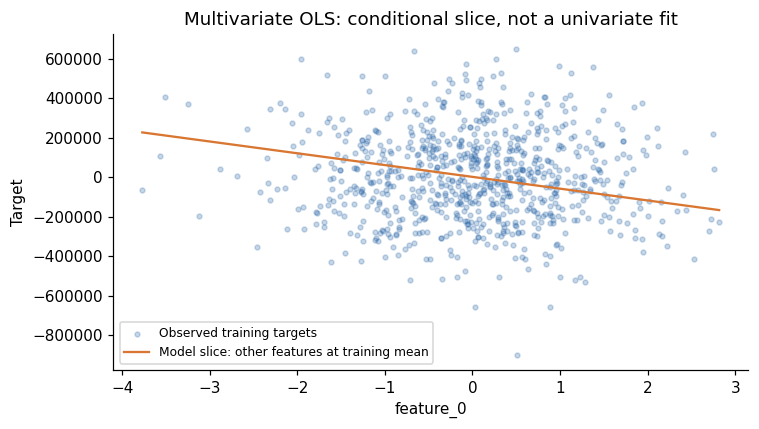

In [4]:
ols_prediction=linear_model.predict(X_test)
ols_residual=y_test.to_numpy()-ols_prediction
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(y_test,ols_prediction,s=15,alpha=.5,color=COLORS[0])
lims=[min(y_test.min(),ols_prediction.min()),max(y_test.max(),ols_prediction.max())]
axes[0].plot(lims,lims,"--",color="black",linewidth=1)
axes[0].set(xlabel="True target",ylabel="Predicted target",title="OLS: test predictions")
axes[0].ticklabel_format(style="sci",axis="both",scilimits=(0,0))
axes[1].scatter(ols_prediction,ols_residual,s=15,alpha=.5,color=COLORS[1])
axes[1].axhline(0,color="black",linestyle="--",linewidth=1)
axes[1].set(xlabel="Predicted target",ylabel="Residual (true − predicted)",title="OLS: test residuals")
axes[1].ticklabel_format(style="sci",axis="both",scilimits=(0,0))
plt.tight_layout();plt.show()

# Irisan kondisional multivariat: fitur lain tetap pada mean TRAINING.
conditional_frame=pd.DataFrame(np.tile(X_train.mean().to_numpy(),(150,1)),columns=feature_names)
conditional_frame["feature_0"]=np.linspace(X_train["feature_0"].min(),X_train["feature_0"].max(),150)
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(X_train["feature_0"],y_train,s=10,alpha=.25,color=COLORS[0],label="Observed training targets")
ax.plot(conditional_frame["feature_0"],linear_model.predict(conditional_frame),
        color=COLORS[1],label="Model slice: other features at training mean")
ax.set(xlabel="feature_0",ylabel="Target",title="Multivariate OLS: conditional slice, not a univariate fit")
ax.legend(fontsize=8);plt.tight_layout();plt.show()

### Interpretasi OLS

Scatter actual vs predicted dan residual memakai seluruh fitur melalui prediksi model, sehingga lebih tepat untuk mengevaluasi regresi multivariat. Garis terhadap satu fitur adalah **irisan prediksi** dengan fitur lain ditahan pada mean training. Karena fitur 0 dan 50 berkorelasi, sebagian kombinasi pada irisan tersebut bisa tidak umum dijumpai dalam data. Garis itu tidak boleh ditafsirkan sebagai bukti hubungan sebab-akibat atau fit sederhana atas scatter marginal.

## 4. Ridge dan Lasso

Ridge menambahkan penalti L2 untuk mengecilkan koefisien. Dalam konvensi `sklearn.linear_model.Ridge`:

$$\min_{b,w}\|y-b-Xw\|_2^2+\alpha\|w\|_2^2.$$

Lasso menambahkan penalti L1, yang dapat menghasilkan koefisien tepat nol. Konvensi `Lasso` adalah:

$$\min_{b,w}\frac{1}{2n}\|y-b-Xw\|_2^2+\alpha\|w\|_1.$$

Karena normalisasi loss berbeda, nilai alpha yang sama pada Ridge dan Lasso tidak berarti kekuatan penalti yang sama. Alpha besar biasanya meningkatkan penyusutan serta bias; alpha terlalu besar dapat underfit. Ridge cenderung mempertahankan fitur berkorelasi, sedangkan Lasso dapat memilih sebagian di antaranya secara tidak stabil. Intercept tidak dipenalti oleh estimator dengan pengaturan default.

### Reproduksi parameter buku

Ridge memakai alpha=1 dan Lasso alpha=10 pada data asli seperti resep. Semua fitur generator memiliki skala yang relatif serupa. Bagian CV nanti menambahkan standardisasi secara eksplisit. Iterasi Lasso diperbesar untuk data multikolinear; warning konvergensi tidak disembunyikan.

In [5]:
ridge_model=Ridge(alpha=1.0).fit(X_train,y_train)
lasso_model=Lasso(alpha=10.0,max_iter=100000,tol=1e-4).fit(X_train,y_train)
recipe_models.update({"Ridge alpha=1":ridge_model,"Lasso alpha=10":lasso_model})
for name,model in [("Ridge alpha=1",ridge_model),("Lasso alpha=10",lasso_model)]:
    recipe_metric_rows+=regression_metrics(name,model,X_train,X_test,y_train,y_test)
display(pd.DataFrame(recipe_metric_rows).round(3))
print("Lasso iterations:",lasso_model.n_iter_)
print("Lasso nonzero coefficients:",np.count_nonzero(lasso_model.coef_))
coef_comparison=pd.DataFrame({
    "OLS":linear_model.coef_,"Ridge alpha=1":ridge_model.coef_,"Lasso alpha=10":lasso_model.coef_
},index=feature_names)
display(coef_comparison.head(10).round(3))

Lasso iterations: 1520
Lasso nonzero coefficients: 100


,model,split,MSE,RMSE,MAE,R²
0,OLS,train,3.395737e+10,184275.248,147199.078,0.323
1,OLS,test,4.655059e+10,215755.860,173597.056,0.065
2,Mean baseline,train,5.017377e+10,223995.024,179416.105,0.000
3,Mean baseline,test,4.978558e+10,223126.818,177968.715,-0.000
4,Ridge alpha=1,train,3.406323e+10,184562.257,147304.780,0.321
5,Ridge alpha=1,test,4.534109e+10,212934.478,171751.466,0.089
6,Lasso alpha=10,train,3.395943e+10,184280.851,147204.957,0.323
7,Lasso alpha=10,test,4.637714e+10,215353.524,173369.981,0.068


,OLS,Ridge alpha=1,Lasso alpha=10
feature_0,-59719.824,-40256.883,-56383.499
feature_1,-111331.066,-82165.912,-109121.170
feature_2,-134928.903,-105275.950,-132811.684
feature_3,-107805.295,-78652.587,-105201.246
feature_4,-19198.013,-15056.796,-16348.509
feature_5,38248.839,39145.123,36188.412
feature_6,-20251.187,-18642.833,-18084.123
feature_7,4860.881,5545.673,5190.063
feature_8,-1894.581,1254.962,-1874.312
feature_9,25740.274,12254.588,22412.524


### Analisis regularisasi

Bandingkan train dan test terhadap OLS serta baseline. Regularisasi dapat menurunkan varians koefisien, tetapi tidak dijamin memberi skor test lebih baik pada setiap seed. Alpha=10 pada target berskala ratusan ribu dapat terlalu kecil untuk menghasilkan banyak nol; tidak munculnya nol bukan error Lasso. Koefisien nol pada dataset sintetis juga bukan bukti bahwa fitur tidak relevan secara kausal.

## 5. ElasticNet dan coefficient paths

ElasticNet menggabungkan L1 dan L2. Dengan rho = `l1_ratio`, fungsi objektif sklearn adalah:

$$\frac{1}{2n}\|y-b-Xw\|_2^2+\alpha\rho\|w\|_1+\frac{\alpha(1-\rho)}{2}\|w\|_2^2.$$

Rho mendekati 1 memberi lebih banyak penalti L1; rho mendekati 0 memberi lebih banyak L2. Parameter alpha mengatur kekuatan penalti gabungan. Resep model tetap memakai alpha=1 dan l1_ratio=0.5. Rentang alpha yang efektif bergantung pada skala X, y, dan konvensi loss.

In [6]:
elastic_model=ElasticNet(alpha=1.0,l1_ratio=0.5,random_state=RANDOM_STATE,
                         max_iter=100000,tol=1e-4).fit(X_train,y_train)
recipe_models["ElasticNet alpha=1, ratio=.5"]=elastic_model
recipe_metric_rows+=regression_metrics("ElasticNet alpha=1, ratio=.5",elastic_model,
                                      X_train,X_test,y_train,y_test)
recipe_results=pd.DataFrame(recipe_metric_rows)
display(recipe_results.round(3))
print("ElasticNet nonzero coefficients:",np.count_nonzero(elastic_model.coef_))
print("ElasticNet iterations:",elastic_model.n_iter_)

ElasticNet nonzero coefficients: 100
ElasticNet iterations: 21


,model,split,MSE,RMSE,MAE,R²
0,OLS,train,3.395737e+10,184275.248,147199.078,0.323
1,OLS,test,4.655059e+10,215755.860,173597.056,0.065
2,Mean baseline,train,5.017377e+10,223995.024,179416.105,0.000
3,Mean baseline,test,4.978558e+10,223126.818,177968.715,-0.000
4,Ridge alpha=1,train,3.406323e+10,184562.257,147304.780,0.321
5,Ridge alpha=1,test,4.534109e+10,212934.478,171751.466,0.089
6,Lasso alpha=10,train,3.395943e+10,184280.851,147204.957,0.323
7,Lasso alpha=10,test,4.637714e+10,215353.524,173369.981,0.068
8,"ElasticNet alpha=1, ratio=.5",train,3.639762e+10,190781.597,152259.353,0.275
9,"ElasticNet alpha=1, ratio=.5",test,4.261664e+10,206437.970,167500.089,0.144


### Path koefisien pada skala standar

Mengikuti resep, tujuh alpha `[0.0001, 0.001, 0.01, 0.1, 1, 10, 100]` disilangkan dengan lima l1_ratio. Untuk membuat penyusutan mudah dibandingkan, **hanya pada demonstrasi path ini** X dan y distandardisasi menggunakan training. Koefisien kemudian menyatakan perubahan dalam satuan simpangan baku y per simpangan baku fitur.

Setiap panel menampilkan 100 garis koefisien. Panel dipisahkan menurut l1_ratio agar plot tidak menumpuk 500 garis pada satu bidang. Diagram path merupakan alat untuk memahami penalti; parameter akhir tetap dipilih dengan CV.

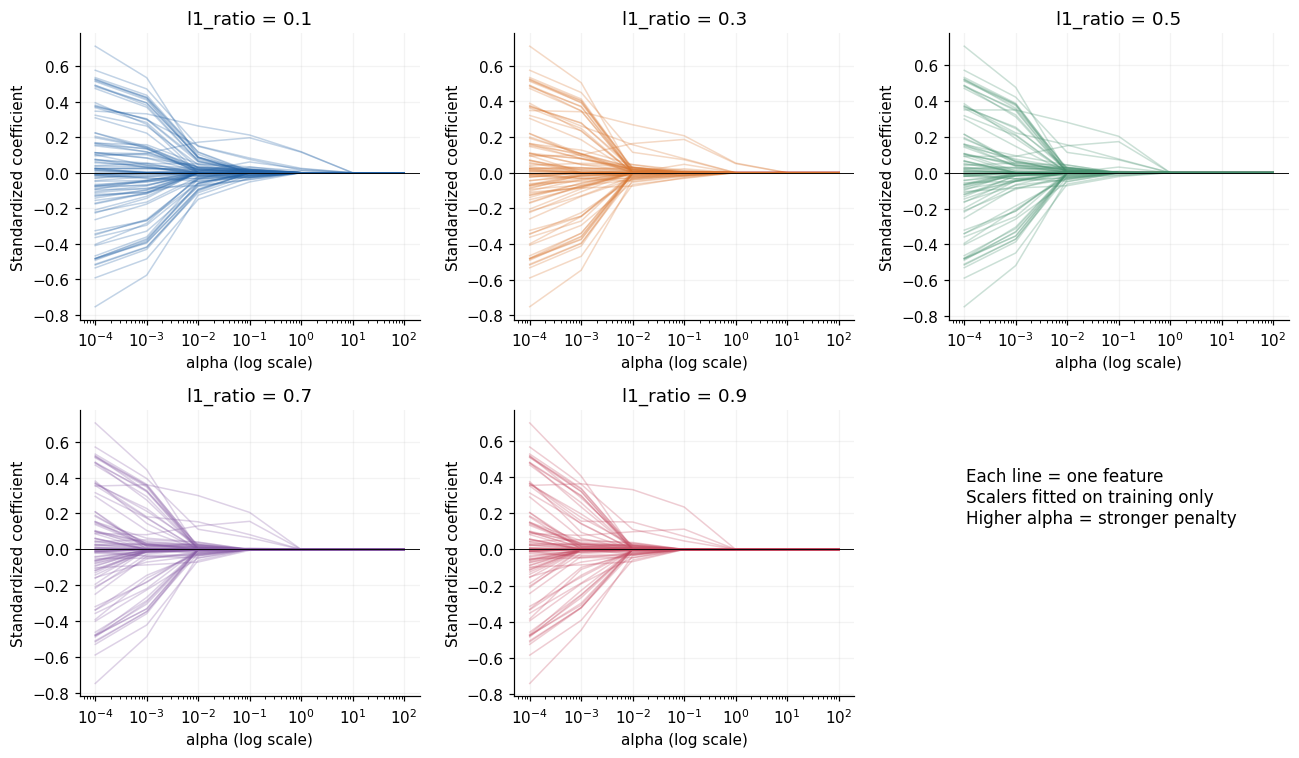

,l1_ratio,alpha,nonzero coefficients,L2 norm
0,0.1,0.0001,100,2.9987
3,0.1,0.1000,59,0.3437
4,0.1,1.0000,6,0.1702
6,0.1,100.0000,0,0.0000
7,0.3,0.0001,100,2.9775
10,0.3,0.1000,31,0.3108
11,0.3,1.0000,2,0.0748
13,0.3,100.0000,0,0.0000
14,0.5,0.0001,100,2.9563
17,0.5,0.1000,16,0.2910


In [7]:
path_x_scaler=StandardScaler().fit(X_train)
path_y_scaler=StandardScaler().fit(y_train.to_numpy().reshape(-1,1))
Xp=path_x_scaler.transform(X_train)
yp=path_y_scaler.transform(y_train.to_numpy().reshape(-1,1)).ravel()
alphas=np.array([0.0001,0.001,0.01,0.1,1,10,100])
l1_ratios=[0.1,0.3,0.5,0.7,0.9]
fig,axes=plt.subplots(2,3,figsize=(12,7))
path_rows=[]
for ax,ratio,color in zip(axes.ravel(),l1_ratios,COLORS):
    coefs=[]
    for alpha in alphas:
        fitted=ElasticNet(alpha=alpha,l1_ratio=ratio,max_iter=100000,tol=1e-4,
                          random_state=RANDOM_STATE).fit(Xp,yp)
        coefs.append(fitted.coef_)
        path_rows.append({"l1_ratio":ratio,"alpha":alpha,
                          "nonzero coefficients":int(np.count_nonzero(fitted.coef_)),
                          "L2 norm":np.linalg.norm(fitted.coef_)})
    ax.plot(alphas,np.asarray(coefs),color=color,alpha=.28,linewidth=1)
    ax.set(xscale="log",xlabel="alpha (log scale)",ylabel="Standardized coefficient",
           title=f"l1_ratio = {ratio}")
    ax.axhline(0,color="black",linewidth=.6);ax.grid(alpha=.15)
axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(.05,.8,chr(10).join(["Each line = one feature", "Scalers fitted on training only", "Higher alpha = stronger penalty"]), va="top",fontsize=11)
plt.tight_layout();plt.show()
path_results=pd.DataFrame(path_rows)
display(path_results[path_results["alpha"].isin([0.0001,0.1,1,100])].round(4))

### Interpretasi path

Perhatikan jumlah koefisien nonzero ketika alpha meningkat. Dalam data berkorelasi, lintasan masing-masing koefisien tidak harus monoton karena fitur saling menggantikan kontribusi. Model pada path dengan y terstandar tidak dapat langsung dibandingkan koefisiennya dengan model resep yang memakai y asli. Untuk alpha=0, gunakan `LinearRegression` daripada mengandalkan solver Lasso sebagai OLS.

## 6. Tambahan — memilih model dengan training CV

Gunakan `TransformedTargetRegressor`: scaler X berada dalam pipeline regressor dan scaler y berada dalam transformer target. GridSearchCV melatih **seluruh pembungkus** pada masing-masing training fold, sehingga baik skala X maupun y tidak melihat validation. Prediksi otomatis dikembalikan ke satuan target asli sebelum scoring.

Empat keluarga model dicoba dengan rentang penalti yang ditetapkan sebelumnya. Scoring adalah negative RMSE karena sklearn memilih skor maksimum. Tabel ditampilkan sebagai RMSE positif sehingga **lebih kecil lebih baik**. Pemilihan ini tidak berdasarkan test; skor terbaik CV tetap bisa optimistis karena banyak kandidat dibandingkan.

In [8]:
scaled_regressor=TransformedTargetRegressor(
    regressor=Pipeline([("scaler",StandardScaler()),("model",LinearRegression())]),
    transformer=StandardScaler())
regularization_grid=[
    {"regressor__model":[LinearRegression()]},
    {"regressor__model":[Ridge()],"regressor__model__alpha":[0.1,1,10,100]},
    {"regressor__model":[Lasso(max_iter=100000)],
     "regressor__model__alpha":[0.0001,0.001,0.01,0.1]},
    {"regressor__model":[ElasticNet(max_iter=100000,random_state=RANDOM_STATE)],
     "regressor__model__alpha":[0.001,0.01,0.1,1],
     "regressor__model__l1_ratio":[0.1,0.5,0.9]},
]
cv=KFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
regularization_search=GridSearchCV(scaled_regressor,regularization_grid,cv=cv,
    scoring="neg_root_mean_squared_error",n_jobs=1,error_score="raise")
regularization_search.fit(X_train,y_train)
reg_cv=pd.DataFrame(regularization_search.cv_results_)
reg_cv["model"]=reg_cv["params"].map(lambda p:type(p["regressor__model"]).__name__)
reg_cv["CV RMSE"]=-reg_cv["mean_test_score"]
display(reg_cv[["model","param_regressor__model__alpha","param_regressor__model__l1_ratio",
                "CV RMSE","std_test_score","rank_test_score"]].sort_values("CV RMSE").head(10).round(3))
print("Selected by training CV:",regularization_search.best_params_)
print("Selected mean CV RMSE:",round(-regularization_search.best_score_,3))

Selected by training CV: {'regressor__model': ElasticNet(max_iter=100000, random_state=123), 'regressor__model__alpha': 0.1, 'regressor__model__l1_ratio': 0.5}
Selected mean CV RMSE: 198247.45


,model,param_regressor__model__alpha,param_regressor__model__l1_ratio,CV RMSE,std_test_score,rank_test_score
16,ElasticNet,0.10,0.5,198247.450,9436.721,1
17,ElasticNet,0.10,0.9,198909.171,10889.643,2
8,Lasso,0.10,NaN,199462.366,11060.374,3
15,ElasticNet,0.10,0.1,201299.816,7858.614,4
7,Lasso,0.01,NaN,201976.827,8353.304,5
14,ElasticNet,0.01,0.9,202238.365,8341.448,6
13,ElasticNet,0.01,0.5,203382.140,8423.296,7
4,Ridge,100.00,NaN,203713.443,7863.712,8
18,ElasticNet,1.00,0.1,203994.833,10373.758,9
12,ElasticNet,0.01,0.1,205302.336,8198.078,10


In [9]:
selected_regression_metrics=pd.DataFrame(regression_metrics(
    "CV-selected model",regularization_search,X_train,X_test,y_train,y_test))
display(selected_regression_metrics.round(3))
print("Training target mean learned by selected wrapper:",
      round(regularization_search.best_estimator_.transformer_.mean_[0],3))
print("Actual training target mean:",round(y_train.mean(),3))
assert np.isclose(regularization_search.best_estimator_.transformer_.mean_[0],y_train.mean())

Training target mean learned by selected wrapper: 1900.111
Actual training target mean: 1900.111


,model,split,MSE,RMSE,MAE,R²
0,CV-selected model,train,3.819467e+10,195434.570,155541.042,0.239
1,CV-selected model,test,3.934796e+10,198363.191,160446.066,0.209


### Analisis model hasil CV

Skor final berlaku untuk model yang telah dipilih dari training. Jika model itu tidak mengungguli setiap model resep pada test, jangan memilih ulang berdasarkan test. Selisih satu split dapat berasal dari variasi sampel. Standarisasi target membantu mendefinisikan grid alpha yang masuk akal, namun tidak menciptakan informasi baru dan tidak mengembalikan sinyal fitur yang ditimpa saat generator dibuat.

## 7. Polynomial Regression pada pola nonlinier

Resep buku membuat x seragam pada [−50,50] dengan target `2x + 27 sin(x/8) + noise`, sebanyak 1.000 sampel. PolynomialFeatures membentuk basis 1, x, x², dan seterusnya. Model tetap linear dalam koefisien. Untuk p fitur dan degree d, jumlah basis sampai degree d termasuk bias adalah kombinasi (p+d pilih d), sehingga dimensinya cepat membesar.

Degree 1–5 dipilih melalui lima-fold CV pada training. Input distandardisasi sebelum pembentukan pangkat untuk mengurangi persoalan numerik; `include_bias=False` menghindari kolom konstanta tambahan karena estimator sudah memiliki intercept. Test disisihkan terlebih dahulu dan tidak dipakai untuk memilih degree.

In [10]:
rng_nonlinear=np.random.RandomState(RANDOM_STATE)
X_nonlinear=pd.DataFrame({"feature1":rng_nonlinear.uniform(-50,50,1000)})
y_nonlinear=pd.Series(2*X_nonlinear["feature1"].to_numpy()
    +27*np.sin(X_nonlinear["feature1"].to_numpy()/8)
    +rng_nonlinear.normal(0,4,1000),name="target")
Xn_train,Xn_test,yn_train,yn_test=train_test_split(
    X_nonlinear,y_nonlinear,test_size=.2,random_state=RANDOM_STATE)
assert set(Xn_train.index).isdisjoint(Xn_test.index)
print("Nonlinear dataset:",X_nonlinear.shape,
      "| missing:",int(X_nonlinear.isna().sum().sum()),
      "| duplicates:",int(X_nonlinear.duplicated().sum()))
poly_pipeline=Pipeline([("input_scale",StandardScaler()),
                        ("basis",PolynomialFeatures(include_bias=False)),
                        ("model",LinearRegression())])
poly_search=GridSearchCV(poly_pipeline,{"basis__degree":[1,2,3,4,5]},
    cv=cv,scoring="neg_root_mean_squared_error",n_jobs=1,error_score="raise")
poly_search.fit(Xn_train,yn_train)
poly_cv=pd.DataFrame({"degree":poly_search.cv_results_["param_basis__degree"],
                      "CV RMSE":-poly_search.cv_results_["mean_test_score"],
                      "CV std":poly_search.cv_results_["std_test_score"]})
display(poly_cv.round(4))
print("Degree selected by training CV:",poly_search.best_params_["basis__degree"])

Nonlinear dataset: (1000, 1) | missing: 0 | duplicates: 0
Degree selected by training CV: 5


,degree,CV RMSE,CV std
0,1,18.5134,0.5088
1,2,18.5157,0.5098
2,3,16.7382,0.4710
3,4,16.8196,0.5280
4,5,6.9209,0.1611


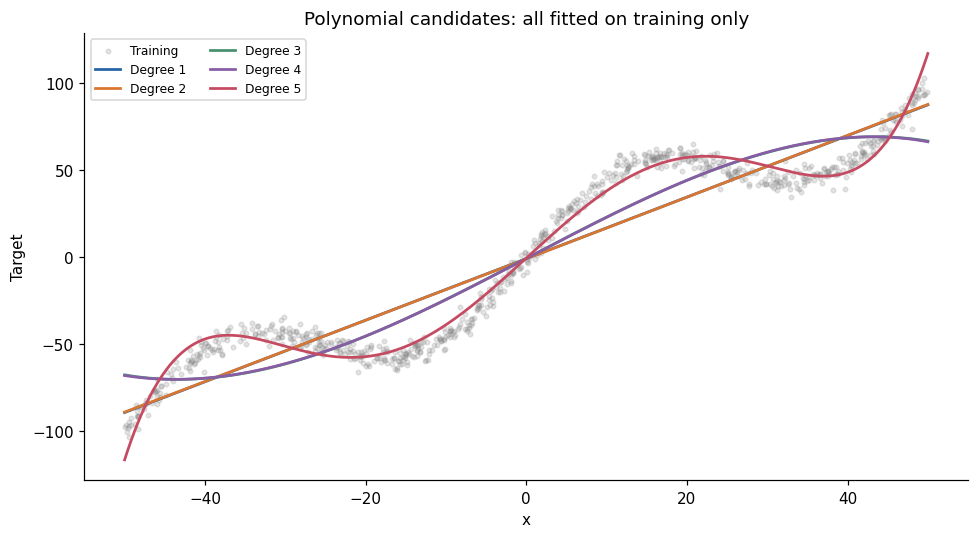

In [11]:
from sklearn.base import clone
plot_grid=pd.DataFrame({"feature1":np.linspace(-50,50,500)})
fig,ax=plt.subplots(figsize=(9,5))
ax.scatter(Xn_train["feature1"],yn_train,s=9,color="gray",alpha=.2,label="Training")
for degree,color in zip([1,2,3,4,5],COLORS):
    candidate=clone(poly_pipeline).set_params(basis__degree=degree).fit(Xn_train,yn_train)
    ax.plot(plot_grid["feature1"],candidate.predict(plot_grid),color=color,
            linewidth=1.8,label=f"Degree {degree}")
ax.set(xlabel="x",ylabel="Target",title="Polynomial candidates: all fitted on training only")
ax.legend(ncol=2,fontsize=8);plt.tight_layout();plt.show()

### Analisis polynomial

Degree lebih tinggi memberi kelenturan, tetapi juga meningkatkan kemungkinan overfitting serta ketidakstabilan ekstrapolasi. Kurva dipasang menggunakan training yang sama; tidak ada refit pada seluruh dataset hanya agar grafik terlihat lebih bagus. Pada satu test set yang sama, memilih MSE minimum dan R² maksimum memberikan urutan model yang sama karena keduanya bergantung pada jumlah kuadrat residual yang sama. Yang perlu dijaga adalah data yang digunakan untuk memilih model tersebut.

## 8. Spline basis dan evaluasi nonlinier

SplineTransformer membuat basis B-spline berupa polynomial lokal yang bertemu pada knots. Dengan `LinearRegression`, koefisien basis dipelajari melalui least squares. Model ini merupakan **spline regression** dan tidak harus melewati semua titik berisik seperti interpolasi eksak.

Mengikuti sumber, degree=3 dan n_knots=[3,5,7]. Posisi knots dipelajari dari training setiap fold karena transformer berada di pipeline. `extrapolation="constant"` menetapkan perilaku basis di luar rentang training. Banyaknya knots mengatur fleksibilitas lokal dan dipilih melalui CV.

Knots selected by training CV: 7
Family selected using training CV: Spline


,knots,CV RMSE,CV std
0,3,16.8166,0.5488
1,5,7.5059,0.1777
2,7,3.9536,0.3302


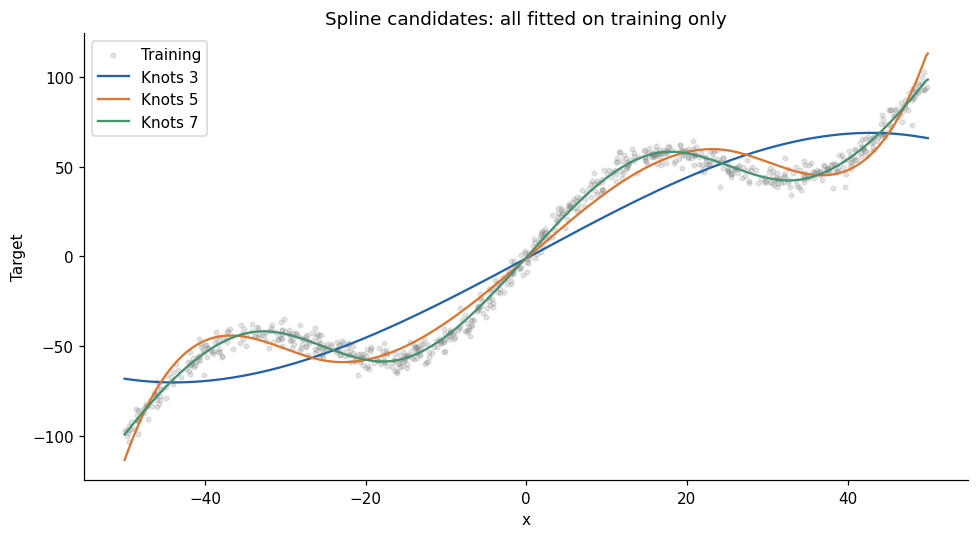

In [12]:
spline_pipeline=Pipeline([
    ("basis",SplineTransformer(degree=3,include_bias=False,extrapolation="constant")),
    ("model",LinearRegression()),
])
spline_search=GridSearchCV(spline_pipeline,{"basis__n_knots":[3,5,7]},
    cv=cv,scoring="neg_root_mean_squared_error",n_jobs=1,error_score="raise")
spline_search.fit(Xn_train,yn_train)
spline_cv=pd.DataFrame({"knots":spline_search.cv_results_["param_basis__n_knots"],
                        "CV RMSE":-spline_search.cv_results_["mean_test_score"],
                        "CV std":spline_search.cv_results_["std_test_score"]})
display(spline_cv.round(4))
print("Knots selected by training CV:",spline_search.best_params_["basis__n_knots"])
nonlinear_selected_name=("Polynomial" if poly_search.best_score_>=spline_search.best_score_ else "Spline")
print("Family selected using training CV:",nonlinear_selected_name)
fig,ax=plt.subplots(figsize=(9,5))
ax.scatter(Xn_train["feature1"],yn_train,s=9,color="gray",alpha=.2,label="Training")
for knots,color in zip([3,5,7],COLORS):
    candidate=clone(spline_pipeline).set_params(basis__n_knots=knots).fit(Xn_train,yn_train)
    ax.plot(plot_grid["feature1"],candidate.predict(plot_grid),color=color,label=f"Knots {knots}")
ax.set(xlabel="x",ylabel="Target",title="Spline candidates: all fitted on training only")
ax.legend();plt.tight_layout();plt.show()

,model,split,MSE,RMSE,MAE,R²
0,Mean baseline,train,2861.0434,53.4887,50.0529,0.0000
1,Mean baseline,test,2944.8696,54.2667,50.8107,-0.0113
2,Linear degree 1,train,342.1432,18.4971,15.9046,0.8804
3,Linear degree 1,test,317.0050,17.8046,15.2525,0.8911
4,Polynomial,train,46.5019,6.8192,5.6726,0.9837
5,Polynomial,test,48.3162,6.9510,5.7195,0.9834
6,Spline,train,15.3827,3.9221,3.0936,0.9946
7,Spline,test,16.2539,4.0316,3.3487,0.9944


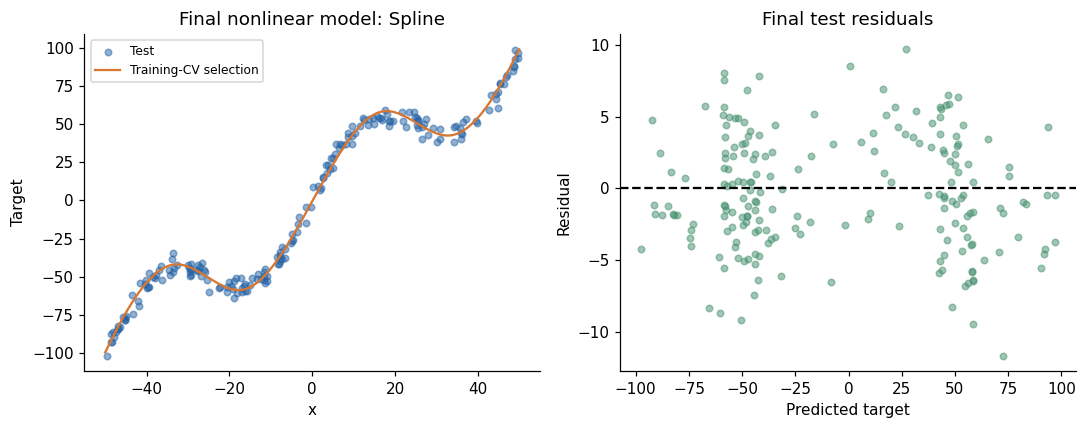

In [13]:
nonlinear_baseline=DummyRegressor().fit(Xn_train,yn_train)
nonlinear_linear=LinearRegression().fit(Xn_train,yn_train)
nonlinear_models={"Mean baseline":nonlinear_baseline,"Linear degree 1":nonlinear_linear,
                  "Polynomial":poly_search,"Spline":spline_search}
nonlinear_rows=[]
for name,model in nonlinear_models.items():
    nonlinear_rows+=regression_metrics(name,model,Xn_train,Xn_test,yn_train,yn_test)
nonlinear_results=pd.DataFrame(nonlinear_rows)
display(nonlinear_results.round(4))
chosen_nonlinear=nonlinear_models[nonlinear_selected_name]
pred_nonlinear=chosen_nonlinear.predict(Xn_test)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(Xn_test["feature1"],yn_test,s=18,color=COLORS[0],alpha=.5,label="Test")
axes[0].plot(plot_grid["feature1"],chosen_nonlinear.predict(plot_grid),color=COLORS[1],label="Training-CV selection")
axes[0].set(xlabel="x",ylabel="Target",title=f"Final nonlinear model: {nonlinear_selected_name}")
axes[0].legend(fontsize=8)
axes[1].scatter(pred_nonlinear,yn_test.to_numpy()-pred_nonlinear,s=18,color=COLORS[2],alpha=.5)
axes[1].axhline(0,color="black",linestyle="--")
axes[1].set(xlabel="Predicted target",ylabel="Residual",title="Final test residuals")
plt.tight_layout();plt.show()

### Analisis evaluasi nonlinier

Model yang mengikuti kurva sinus dapat memperbaiki prediksi dibanding garis lurus, tetapi bukti perbaikannya harus dilihat pada test setelah seleksi melalui CV. Residual berpola menunjukkan masih ada struktur yang belum ditangkap. Residual yang tampak acak tidak membuktikan semua asumsi statistik terpenuhi. Dengan noise generator bersimpangan baku 4, kesalahan prediksi tidak diharapkan hilang sepenuhnya.

Semua metrik pada tabel ini berada pada skala target dataset nonlinier. Angkanya tidak sebanding langsung dengan MSE dataset 100 fitur sebelumnya yang targetnya dikalikan 1.000.

## 9. Latihan 1 — Ridge pada hubungan kuadratik

Generator solusi buku membuat 100 titik x pada [−3,3] dengan target 0,5x²+x+noise. Ridge alpha=1 yang diberi **hanya x** tetap menghasilkan garis lurus. Regularisasi tidak otomatis membuat model menjadi nonlinier.

Sebagai tambahan yang ditetapkan sebelum evaluasi, dibandingkan dengan Ridge setelah PolynomialFeatures degree=2. Kedua model memakai split yang sama. Tujuannya menunjukkan perbedaan kapasitas representasi, bukan melakukan pemilihan degree berdasarkan test.

,model,split,MSE,RMSE,MAE,R²
0,"Ridge, original x",train,1.9780,1.4064,1.2294,0.6575
1,"Ridge, original x",test,2.5628,1.6009,1.3400,-0.0360
2,Supplement: degree-2 Ridge,train,0.3294,0.5739,0.4730,0.9430
3,Supplement: degree-2 Ridge,test,0.2761,0.5255,0.4620,0.8884
4,Mean baseline,train,5.7747,2.4031,1.9137,0.0000
5,Mean baseline,test,2.6357,1.6235,1.3902,-0.0655


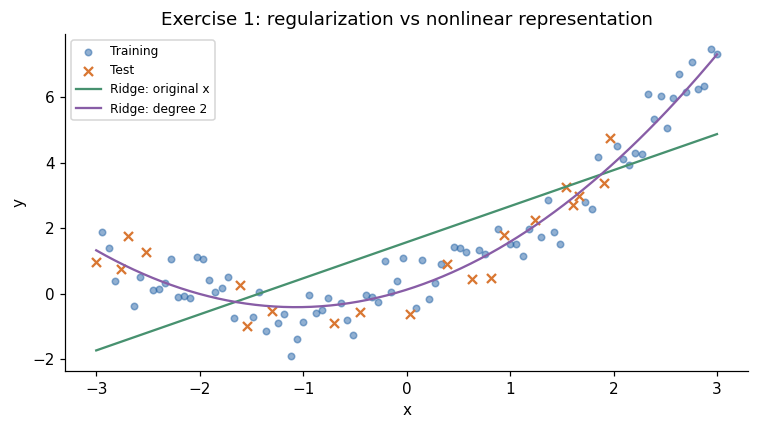

In [14]:
rng_ridge=np.random.RandomState(RANDOM_STATE)
X_ridge=np.linspace(-3,3,100).reshape(-1,1)
y_ridge=.5*X_ridge.ravel()**2+X_ridge.ravel()+rng_ridge.normal(0,.5,100)
Xrt,Xrv,yrt,yrv=train_test_split(X_ridge,y_ridge,test_size=.2,random_state=RANDOM_STATE)
exercise_ridge=Ridge(alpha=1.0).fit(Xrt,yrt)
exercise_poly_ridge=make_pipeline(PolynomialFeatures(degree=2,include_bias=False),
                                 StandardScaler(),Ridge(alpha=1.0)).fit(Xrt,yrt)
exercise_ridge_baseline=DummyRegressor().fit(Xrt,yrt)
ridge_ex_rows=[]
for name,model in [("Ridge, original x",exercise_ridge),
                   ("Supplement: degree-2 Ridge",exercise_poly_ridge),
                   ("Mean baseline",exercise_ridge_baseline)]:
    ridge_ex_rows+=regression_metrics(name,model,Xrt,Xrv,yrt,yrv)
display(pd.DataFrame(ridge_ex_rows).round(4))
line_x=np.linspace(-3,3,200).reshape(-1,1)
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(Xrt.ravel(),yrt,s=18,alpha=.5,label="Training",color=COLORS[0])
ax.scatter(Xrv.ravel(),yrv,s=35,marker="x",label="Test",color=COLORS[1])
ax.plot(line_x.ravel(),exercise_ridge.predict(line_x),color=COLORS[2],label="Ridge: original x")
ax.plot(line_x.ravel(),exercise_poly_ridge.predict(line_x),color=COLORS[3],label="Ridge: degree 2")
ax.set(xlabel="x",ylabel="y",title="Exercise 1: regularization vs nonlinear representation")
ax.legend(fontsize=8);plt.tight_layout();plt.show()

### Analisis latihan 1

Jika Ridge dengan satu fitur belum mengikuti lengkungan, penyebab utamanya adalah bentuk fungsi yang terlalu sederhana. Mengecilkan atau membesarkan alpha tidak menambahkan suku x². PolynomialFeatures memperluas representasi sehingga model dapat mengikuti pola kuadratik; regularisasi kemudian mengendalikan koefisien dalam representasi tersebut.

## 10. Latihan 2 — Lasso pada hubungan linear

Sumber membuat x=2×uniform(0,1), target 4+3x+noise, 100 sampel, dan Lasso alpha=0.1. Target diratakan menjadi vektor satu dimensi supaya bentuk input konsisten dengan regresi satu target. Skala asli dipertahankan untuk mereproduksi parameter latihan; tidak ada tuning pada test.

Fitted intercept: 4.5625 | fitted slope: 2.4508 | generating slope: 3


,model,split,MSE,RMSE,MAE,R²
0,Lasso alpha=.1,train,0.2631,0.5129,0.3827,0.8814
1,Lasso alpha=.1,test,0.4239,0.6511,0.5368,0.8419
2,Mean baseline,train,2.2178,1.4892,1.2585,0.0000
3,Mean baseline,test,2.6832,1.6380,1.3746,-0.0004


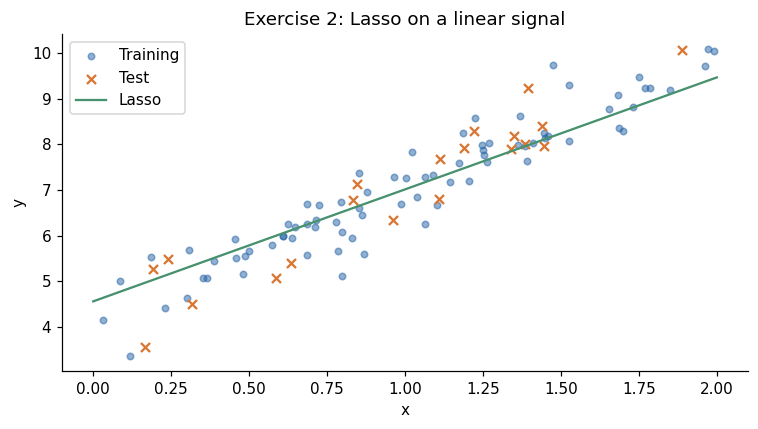

In [15]:
rng_lasso=np.random.RandomState(RANDOM_STATE)
X_lasso=2*rng_lasso.rand(100,1)
y_lasso=(4+3*X_lasso+rng_lasso.randn(100,1)*.5).ravel()
Xlt,Xlv,ylt,ylv=train_test_split(X_lasso,y_lasso,test_size=.2,random_state=RANDOM_STATE)
exercise_lasso=Lasso(alpha=.1,max_iter=100000).fit(Xlt,ylt)
exercise_lasso_baseline=DummyRegressor().fit(Xlt,ylt)
lasso_ex_rows=regression_metrics("Lasso alpha=.1",exercise_lasso,Xlt,Xlv,ylt,ylv)
lasso_ex_rows+=regression_metrics("Mean baseline",exercise_lasso_baseline,Xlt,Xlv,ylt,ylv)
display(pd.DataFrame(lasso_ex_rows).round(4))
print("Fitted intercept:",round(exercise_lasso.intercept_,4),
      "| fitted slope:",round(exercise_lasso.coef_[0],4),"| generating slope: 3")
line_x=np.linspace(0,2,200).reshape(-1,1)
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(Xlt.ravel(),ylt,s=18,alpha=.5,label="Training",color=COLORS[0])
ax.scatter(Xlv.ravel(),ylv,s=35,marker="x",label="Test",color=COLORS[1])
ax.plot(line_x.ravel(),exercise_lasso.predict(line_x),color=COLORS[2],label="Lasso")
ax.set(xlabel="x",ylabel="y",title="Exercise 2: Lasso on a linear signal")
ax.legend();plt.tight_layout();plt.show()

### Analisis latihan 2

Slope dapat lebih kecil daripada slope generator karena penalti L1 menyusutkan koefisien dan data memiliki noise. Pada contoh satu fitur, seleksi fitur hanya mempunyai dua kemungkinan: mempertahankan fitur atau menjadikannya nol. Untuk menjelaskan sparsity multivariat, path 100 fitur di bagian 5 lebih informatif.

## 11. Latihan 3 — ElasticNet pada tren linear dengan sinus

Solusi buku memakai 200 titik x pada [−10,10], target 3x+2sin(x)+noise bersimpangan baku 1,5, alpha=0.1, dan l1_ratio=0.5. Model menerima satu fitur x sehingga dapat menangkap tren linear dominan tetapi tidak seluruh osilasi sinus. Target kembali dijadikan vektor satu dimensi.

,model,split,MSE,RMSE,MAE,R²
0,"ElasticNet alpha=.1, ratio=.5",train,4.6771,2.1627,1.7638,0.9849
1,"ElasticNet alpha=.1, ratio=.5",test,4.0393,2.0098,1.5628,0.9867
2,Mean baseline,train,309.7057,17.5985,15.2994,0.0000
3,Mean baseline,test,339.4469,18.4241,15.9513,-0.1159


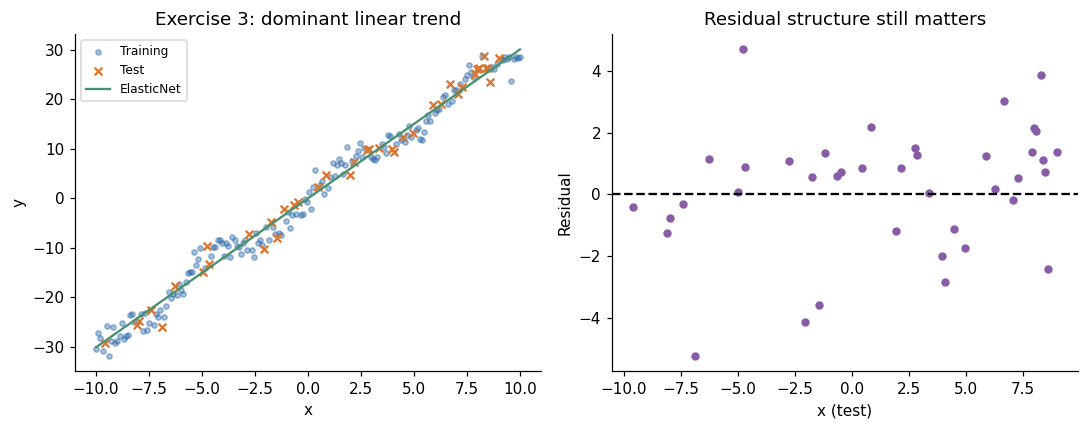

In [16]:
rng_elastic=np.random.RandomState(RANDOM_STATE)
X_elastic=np.linspace(-10,10,200).reshape(-1,1)
y_elastic=(3*X_elastic+2*np.sin(X_elastic)+rng_elastic.normal(0,1.5,X_elastic.shape)).ravel()
Xet,Xev,yet,yev=train_test_split(X_elastic,y_elastic,test_size=.2,random_state=RANDOM_STATE)
exercise_elastic=ElasticNet(alpha=.1,l1_ratio=.5,max_iter=100000,random_state=RANDOM_STATE).fit(Xet,yet)
exercise_elastic_baseline=DummyRegressor().fit(Xet,yet)
elastic_ex_rows=regression_metrics("ElasticNet alpha=.1, ratio=.5",exercise_elastic,Xet,Xev,yet,yev)
elastic_ex_rows+=regression_metrics("Mean baseline",exercise_elastic_baseline,Xet,Xev,yet,yev)
display(pd.DataFrame(elastic_ex_rows).round(4))
line_x=np.linspace(-10,10,300).reshape(-1,1)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].scatter(Xet.ravel(),yet,s=12,alpha=.4,label="Training",color=COLORS[0])
axes[0].scatter(Xev.ravel(),yev,s=25,marker="x",label="Test",color=COLORS[1])
axes[0].plot(line_x.ravel(),exercise_elastic.predict(line_x),color=COLORS[2],label="ElasticNet")
axes[0].set(xlabel="x",ylabel="y",title="Exercise 3: dominant linear trend");axes[0].legend(fontsize=8)
axes[1].scatter(Xev.ravel(),yev-exercise_elastic.predict(Xev),s=20,color=COLORS[3])
axes[1].axhline(0,color="black",linestyle="--")
axes[1].set(xlabel="x (test)",ylabel="Residual",title="Residual structure still matters")
plt.tight_layout();plt.show()

## Catatan hasil eksekusi

Pada eksekusi yang disertakan (4 Oktober 2026), model terpilih melalui CV untuk data berdimensi tinggi adalah ElasticNet dengan alpha 0,1 dan l1_ratio 0,5 pada target yang distandardisasi. R² test sekitar **0,209**. Audit menemukan **7 fitur informatif asli tertimpa** ketika fitur berkorelasi dibuat setelah target dibangkitkan; keterbatasan sinyal ini membantu menjelaskan skor rendah. Pada data nonlinear, spline 7 knot memperoleh RMSE test sekitar **4,032** dan R² **0,994**, dibanding polynomial degree 5 dengan RMSE **6,951**. Pada latihan kuadratik, Ridge linear memiliki R² negatif sekitar **−0,036**, sedangkan tambahan fitur kuadrat menghasilkan sekitar **0,888**. Regularisasi tidak menggantikan kebutuhan bentuk fitur yang sesuai. Angka ini adalah hasil satu rancangan data dan split, bukan jaminan untuk dataset lain.

Perbedaan versi pustaka dapat menghasilkan sedikit perubahan angka.

### Analisis latihan 3

R² dapat tinggi karena rentang tren 3x besar dibanding osilasi sinus dan noise. Skor tinggi tersebut tidak membuktikan semua pola sudah tertangkap. Periksa residual terhadap x untuk melihat struktur yang tersisa. Skor tiga latihan tidak boleh diranking sebagai bukti Ridge/Lasso/ElasticNet terbaik secara umum karena datasetnya berbeda.

## 12. Ringkasan chapter

| Metode | Peran utama | Parameter penting | Batasan |
|---|---|---|---|
| OLS | Meminimalkan kuadrat residual | Bentuk fitur | Koefisien rentan pada multikolinearitas |
| Ridge | Penyusutan L2 | alpha | Tidak melakukan seleksi fitur eksak |
| Lasso | Penyusutan L1 dan sparsity | alpha | Seleksi fitur berkorelasi dapat tidak stabil |
| ElasticNet | Gabungan L1 dan L2 | alpha, l1_ratio | Memerlukan pemilihan dua parameter |
| PolynomialFeatures | Basis pangkat/interaksi | degree | Dimensi, kondisi numerik, dan ekstrapolasi |
| SplineTransformer | Basis polynomial lokal | n_knots, degree, extrapolation | Posisi knots harus dipelajari dari training |
| Pipeline + target transformer | Preprocessing konsisten per fold | Urutan transformer | Seluruh pembungkus harus masuk CV |

**Kesimpulan:** regularisasi mengendalikan kompleksitas koefisien dan tidak menggantikan pemilihan representasi fitur. Alpha bergantung pada skala serta definisi loss. Parameter harus dipilih menggunakan training CV, sementara test tetap menjadi evaluasi akhir. MSE, RMSE, MAE, R², baseline, dan residual memberi informasi yang saling melengkapi. Perbandingan performa hanya masuk akal pada dataset, skala target, dan split yang sama.

### Pertanyaan refleksi

1. Mengapa Ridge dan Lasso dengan alpha yang sama tidak berarti penalti yang sama?
2. Mengapa target dikali 1.000 membuat MSE membesar tanpa otomatis mengubah kualitas relatif model?
3. Mengapa regularisasi tidak membuat Ridge satu fitur menangkap kurva kuadratik?
4. Mengapa knots pada SplineTransformer harus dipelajari hanya dari training fold?
5. Mengapa R² tinggi masih bisa disertai residual yang berpola?

## 13. Referensi

1. John Sukup, *scikit-learn Cookbook*, 3rd ed., Packt, 2025, Chapter 5.
2. [Notebook dan exercise solution resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/main/Chapter_5).
3. [scikit-learn: Linear Models](https://scikit-learn.org/stable/modules/linear_model.html).
4. [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) dan [SplineTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html).
5. [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html), [regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics), dan [common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Kode merupakan reproduksi/adaptasi beratribusi. Bantuan LLM digunakan untuk menyusun penjelasan dan memeriksa kode. Mahasiswa perlu memahami hasil dan menulis refleksinya sendiri sesuai ketentuan kelas.